In [ ]:
import os
import sys
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

from models.autoencoder import Autoenc

In [9]:
def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

In [10]:
def get_features(model_paths, combine_mice=True):
    all_features = []
    for model_path in model_paths:
        cp = torch.load(model_path)

        features = []
        for key, value in cp.items():
            if 'readout' in key and 'features' in key:
                features.append(value.cpu().squeeze().T)
        if combine_mice:
            features = torch.cat(features)
        
        all_features.append(features)
    return all_features

In [11]:
def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    curve = np.zeros(len(k_range))
    for x, y in zip(x_idcs, y_idcs):
        curve += knn_consistency(knns[x], knns[y], ks=k_range) 
    
    curve /= len(x_idcs)

    return curve

In [12]:
model_paths_128 = [
    'runs/newbase/dim128_seed0/model_weights.pth',
    'runs/newbase/dim128_seed42/model_weights.pth',
    'runs/newbase/dim128_seed123/model_weights.pth',
]

model_paths_64 = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

features_128 = get_features(model_paths_128)
features_64 = get_features(model_paths_64)

In [ ]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curves = [
    get_curve(k_range, features_128), 
    get_curve(k_range, features_64), 
]

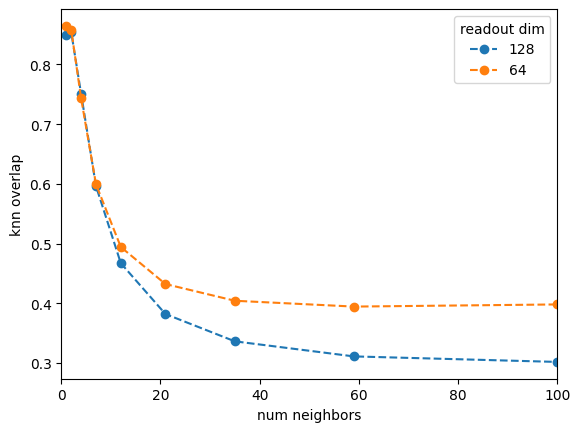

In [14]:
labels = [128, 64]
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, label=label, ls='--', marker='o')

plt.legend(title='readout dim')
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_base.png')
plt.show()

In [9]:
model_paths_128 = [
    'runs/base/exp0/model_weights.pth',
    'runs/base/exp1/model_weights.pth',
    'runs/base/exp2/model_weights.pth',
]

model_paths_64 = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]

model_paths_48 = [
    'runs/base/exp29/model_weights.pth', 
    'runs/base/exp30/model_weights.pth', 
    'runs/base/exp31/model_weights.pth', 
]

model_paths_32 = [
    'runs/base/exp32/model_weights.pth', 
    'runs/base/exp33/model_weights.pth', 
    'runs/base/exp34/model_weights.pth', 
]

features_128 = get_features(model_paths_128)
features_64 = get_features(model_paths_64)
features_48 = get_features(model_paths_48)
features_32 = get_features(model_paths_32)

In [10]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curves = [
    get_curve(k_range, features_128), 
    get_curve(k_range, features_64), 
    get_curve(k_range, features_48), 
    get_curve(k_range, features_32), 
]

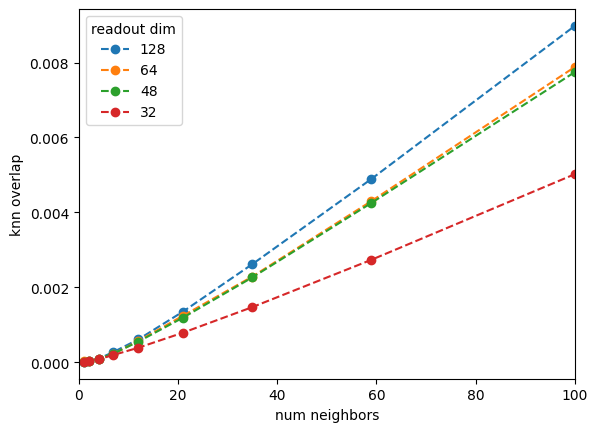

In [11]:
labels = [128, 64, 48, 32]
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, label=label, ls='--', marker='o')

plt.legend(title='readout dim')
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_base.png')
plt.show()

In [9]:
model_paths_128 = [
    'runs/base/exp23/model_weights.pth',
    'runs/base/exp24/model_weights.pth',
    'runs/base/exp25/model_weights.pth',
]

'''
model_paths_64 = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]
'''
model_paths_overcomplete = [
    'runs/base/exp26/model_weights.pth',
    'runs/base/exp27/model_weights.pth',
    'runs/base/exp28/model_weights.pth',
]


In [10]:
features_128 = get_features(model_paths_128)
#features_64 = get_features(model_paths_64)
features_overcomplete = get_features(model_paths_overcomplete)

In [11]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
base_curve_128 = get_curve(k_range, features_128)
base_curve_64 = get_curve(k_range, features_64)
base_curve_overcomplete = get_curve(k_range, features_overcomplete)

In [12]:
pre_sums = []
for features in features_overcomplete:
    pre_sums.append(features[:, :64] + features[:, 64:])

In [13]:
features_overcomplete_linear_sum = []
for features in features_overcomplete:
    weight_sum = features[:, :64] + features[:, 64:]
    scale = torch.rand_like(features[:, :64])

    lienear_sum = torch.zeros_like(features)
    lienear_sum[:, :64] = weight_sum * scale
    lienear_sum[:, 64:] = weight_sum * (1 - scale)
    features_overcomplete_linear_sum.append(lienear_sum)

In [15]:
for features, pre_sum in zip(features_overcomplete_linear_sum, pre_sums):
    post_sum = features[:, :64] + features[:, 64:]
    print((pre_sum - post_sum).max())

tensor(5.9605e-08)
tensor(5.9605e-08)
tensor(5.9605e-08)


In [16]:
base_curve_overcomplete_linear_sum = get_curve(k_range, features_overcomplete_linear_sum)

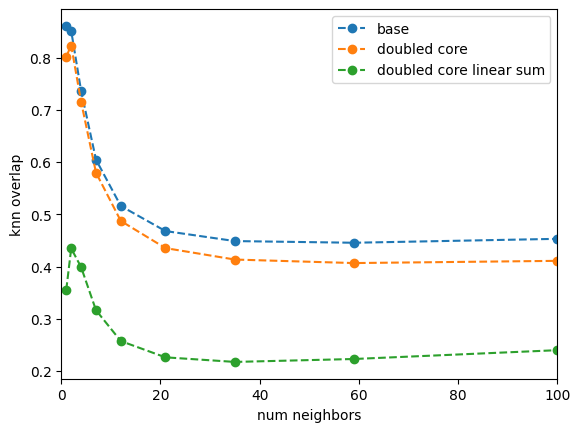

In [17]:
curves = [base_curve_128, base_curve_overcomplete, base_curve_overcomplete_linear_sum]
labels = ['base', 'doubled core', 'doubled core linear sum']
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, ls='--', marker='o', label=label)

plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_overcomplete.png')
plt.show()

In [13]:
latent_dims = [32, 16, 8, 4, 2]

autoenc_paths = [
    [
        'runs/recon_autoenc/exp3/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp4/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp5/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp6/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp7/autoencoder_weights.pth', 
    ],
    [
        'runs/recon_autoenc/exp8/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp9/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp10/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp11/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp12/autoencoder_weights.pth', 
    ],
    [
        'runs/recon_autoenc/exp13/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp14/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp15/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp16/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp17/autoencoder_weights.pth', 
    ],
]

autoencoder_config = {
    'input_dim': 64,
    'hidden_dims': [256, 256, 256],
    'batch_norm': False,
    'nonlinearity': 'ReLU',
}

In [31]:
ks = np.unique(np.geomspace(1, 500, num=20, dtype=int))
knn_curves = []

for i, latent_dim in enumerate(latent_dims):
    print(latent_dim)
    knns = []
    for num_model in range(3):
        autoenc_path = autoenc_paths[num_model][i]
        autoenc = Autoenc(latent_dim=latent_dim, **autoencoder_config)
        autoenc.load_state_dict(torch.load(autoenc_path))
        
        features = all_features[num_model]
        enc_features = autoenc(features).detach().numpy()

        nn = NearestNeighbors(n_neighbors=ks[-1]).fit(enc_features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    knn_curve = (
        knn_consistency(knns[0], knns[1], ks=ks)
        + knn_consistency(knns[0], knns[2], ks=ks)
        + knn_consistency(knns[1], knns[2], ks=ks)
    ) / 3

    knn_curves.append(knn_curve)

32
16
8
4
2


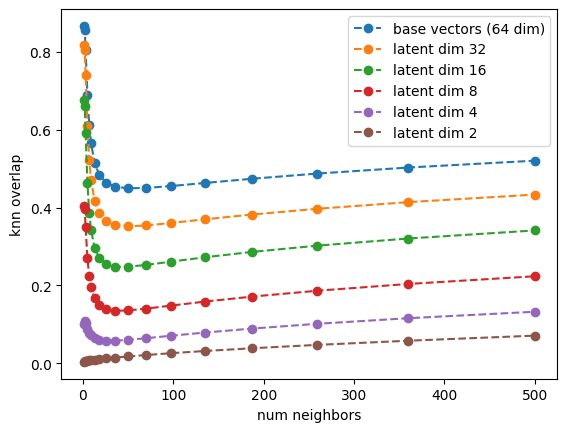

In [40]:
#for leniency, curve in consistencies_dict.items():
plt.plot(ks, base_curve, ls='--', marker='o', label='base vectors (64 dim)')
for latent_dim, curve in zip(latent_dims, knn_curves):
    plt.plot(ks, curve, ls='--', marker='o', label=f'latent dim {latent_dim}')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.legend()
plt.savefig('plots/knn_overlap.png')
plt.show()

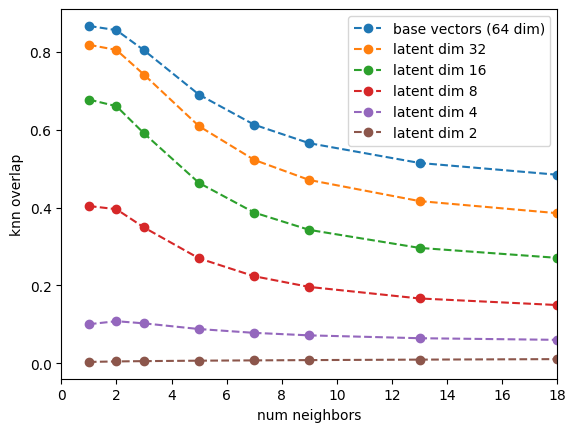

In [41]:
#for leniency, curve in consistencies_dict.items():
plt.plot(ks, base_curve, ls='--', marker='o', label='base vectors (64 dim)')
for latent_dim, curve in zip(latent_dims, knn_curves):
    plt.plot(ks, curve, ls='--', marker='o', label=f'latent dim {latent_dim}')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.legend()
plt.xlim(0, 18)
plt.savefig('plots/knn_overlap_zoom.png')
plt.show()

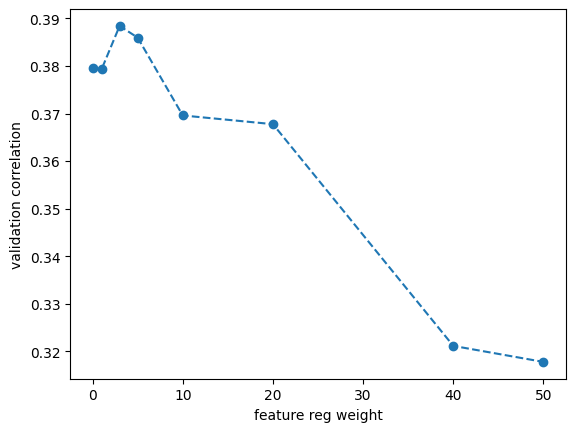

In [9]:
reg_weights = [0, 1, 3, 5, 10, 20, 40, 50]
correlations = [0.37966, 0.37931, 0.38843, 0.38597, 0.3696, 0.36777, 0.32114, 0.31777]
plt.plot(reg_weights, correlations, ls='--', marker='o')
plt.xlabel('feature reg weight')
plt.ylabel('validation correlation')
plt.savefig('plots/readout_reg_correlation.png')
plt.show()

In [69]:
f = features_128[0]

In [70]:
f_norm = f / torch.norm(f, dim=1, keepdim=True)

In [ ]:
N = 10000
idcs = np.random.permutation(f.shape[0])[:N]

cossim = (
    (f_norm[None, :, :] * f_norm[idcs, None, :])
    .sum(dim=-1)
)

neighbors = cossim.argsort(dim=1).flip(dims=[1])

In [63]:
idcs

array([24600, 25103, 51395,  6256, 51612, 17986, 18343, 21639, 50028,
       29065, 27555, 36415, 16372,  1738, 23593,  5014, 15579, 48457,
       46308, 51441, 14541, 11777, 38699, 23265, 42894,  2176, 28912,
       45740, 27543, 10450, 51788, 32618, 35462, 18124,  4071, 47109,
       33732, 24868,  7469, 34920,   433,  4765, 28400, 43427, 31001,
        2626, 29918, 35985, 18583, 23334, 27909, 53156, 18551, 22720,
       16641, 24589, 38499, 52025, 10068, 37863, 47288, 42394, 31669,
       20065, 16440, 34974, 47592, 49189,  1609, 45988, 53804, 18917,
       13290, 53846, 13172, 50150, 46577, 41363, 49890, 21880, 38437,
       14522,  9960, 26139, 34140, 52358, 24821,   649,  7909, 42858,
        1052, 13054, 34840,  3081, 37948, 22039, 38078, 53324, 49019,
        3470])

In [81]:
neighbors[1:5]

tensor([[35282, 34501, 32180,  ..., 43160, 40925, 46803],
        [13028, 13845, 12216,  ..., 13844, 13483, 15213],
        [40213, 43117, 40922,  ..., 25438, 14614, 10354],
        [19677, 20482, 22660,  ..., 50367, 51119, 49557]])

In [10]:
def cos_knn_consistency(knn1, knn2, N, ks):
    n, k_max = knn1.shape
    
    assert ks[-1] <= k_max 
    ranking = np.full((n, N), N, dtype=np.int32)  # Shape (n, N)
    ranking[np.arange(n)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (n, k)
        shared = ranking[np.arange(n)[:, None], neighbours] < k  # Shape (n, k)
        num_shared = shared.sum() / n
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

In [19]:
def get_cossim_curve(k_range, all_features, n=100):
    idcs = np.random.permutation(all_features[0].shape[0])[:n]

    knns = []
    for features in all_features:
        f_norm = features / torch.norm(features, dim=1, keepdim=True)
        cossim = (
            (f_norm[None, :, :] * f_norm[idcs, None, :])
            .sum(dim=-1)
        )
        neighbors = cossim.argsort(dim=1).flip(dims=[1])
        knns.append(neighbors[1:(k_range[-1] + 1)])
        

    #for leniency in leniency_range:
    N=all_features[0].shape[0]
    curve = (
        cos_knn_consistency(knns[0], knns[1], N=N, ks=k_range)
        + cos_knn_consistency(knns[0], knns[2], N=N, ks=k_range)
        + cos_knn_consistency(knns[1], knns[2], N=N, ks=k_range)
    ) / 3

    #consistencies_dict[leniency] = avg_curve
    return curve

In [20]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
cossim_curve_128 = get_cossim_curve(k_range, features_128, n=1000)
cossim_curve_64 = get_cossim_curve(k_range, features_64, n=1000)
cossim_curve_overcomplete = get_cossim_curve(k_range, features_overcomplete, n=1000)

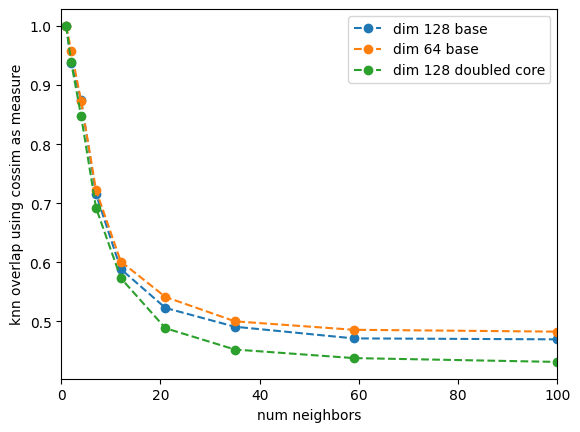

In [22]:
curves = [cossim_curve_128, cossim_curve_64, cossim_curve_overcomplete]
labels = ['dim 128 base', 'dim 64 base', 'dim 128 doubled core']
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, ls='--', marker='o', label=label)

plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('knn overlap using cossim as measure')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_cossim.png')
plt.show()

In [18]:
inv_topo_loss_paths = [
    'runs/topogr/exp4/model_weights.pth', 
    'runs/topogr/exp5/model_weights.pth', 
    #'runs/topogr/exp6/model_weights.pth', 
]

topo_loss_paths = [
    'runs/topogr/exp9/model_weights.pth', 
    'runs/topogr/exp10/model_weights.pth', 
    #'runs/topogr/exp11/model_weights.pth', 
]

topo_features = get_features(topo_loss_paths, combine_mice=False)
base_features = get_features(model_paths_64, combine_mice=False)

# transpose
topo_features = [
    [topo_features[i][j] for i in range(len(topo_features))]
    for j in range(len(topo_features[0]))
]

base_features = [
    [base_features[i][j] for i in range(len(base_features))]
    for j in range(len(base_features[0]))
]

In [16]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
topo_curves = [get_curve(k_range, f) for f in topo_features]
base_curves = [get_curve(k_range, f) for f in base_features]

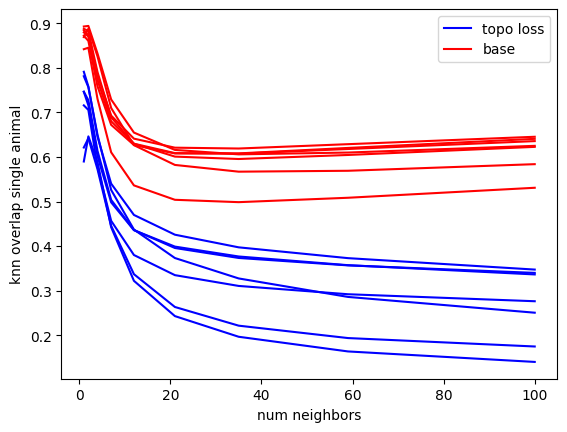

In [ ]:
labeled = False
for curve in topo_curves:
    plt.plot(k_range, curve, c='b', label='topo loss' if not labeled else None)
    labeled = True

labeled = False
for curve in base_curves:
    plt.plot(k_range, curve, c='r', label='base' if not labeled else None)
    labeled = True

plt.xlabel('num neighbors')
plt.ylabel('knn overlap single animal')
plt.legend()
plt.savefig('plots/knn_per_mouse.png')
plt.show()

In [49]:
topo_features = get_features(topo_loss_paths)
inv_topo_features = get_features(inv_topo_loss_paths)

In [50]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
base_curve_64 = get_curve(k_range, features_64)
inv_curve_topo = get_curve(k_range, inv_topo_features)
curve_topo = get_curve(k_range, topo_features)

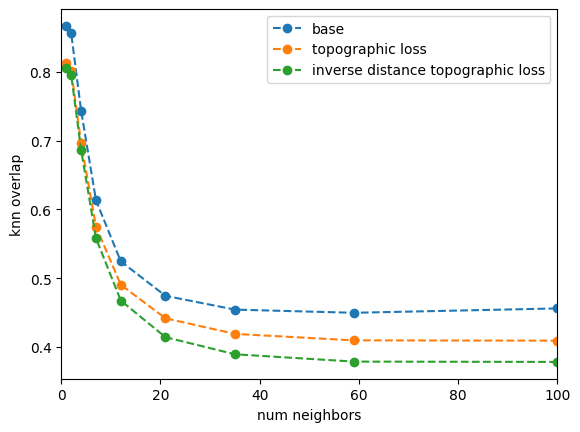

In [52]:
for curve, label in zip(
    [base_curve_64, curve_topo, inv_curve_topo], 
    ['base', 'topographic loss', 'inverse distance topographic loss']
):
    plt.plot(k_range, curve, ls='--', marker='o', label=label)

plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_topographic_loss.png')
plt.show()

In [11]:
topk_paths = [
    'runs/topogr/exp12/model_weights.pth', 
    'runs/topogr/exp13/model_weights.pth', 
    #'runs/topogr/exp14/model_weights.pth', 
]
topk_features = get_features(topk_paths)

k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curve = get_curve(k_range, topk_features)

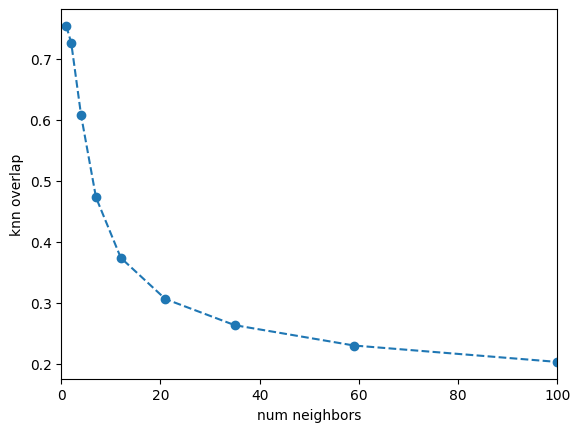

In [12]:
plt.plot(k_range, curve, ls='--', marker='o')
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.show()

In [5]:
base_paths = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]

bottleneck_paths = [
    'runs/bottleneck/exp0/model_weights.pth', 
    'runs/bottleneck/exp1/model_weights.pth', 
    'runs/bottleneck/exp2/model_weights.pth', 
]

base_features = get_features(base_paths)
bottleneck_features = get_features(bottleneck_paths)

In [49]:
from models.bottleneck import Bottleneck

bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
)

bottleneck_embeds = []
for features, path in zip(bottleneck_features, bottleneck_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)

    bottleneck_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )

In [50]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curves = [
    get_curve(k_range, base_features), 
    get_curve(k_range, bottleneck_embeds), 
]

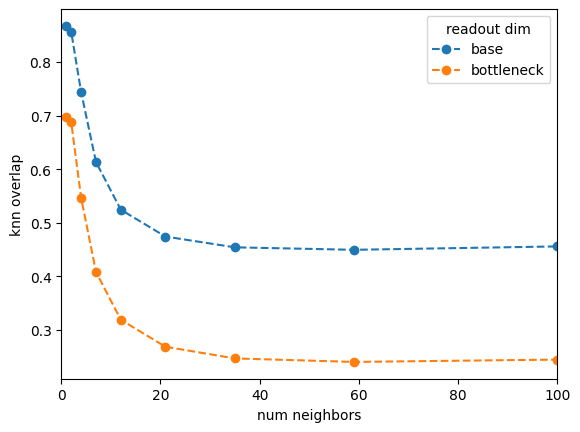

In [51]:
labels = ['base', 'bottleneck']
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, label=label, ls='--', marker='o')

plt.legend(title='readout dim')
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_base.png')
plt.show()

In [12]:
from nnfabrik.builder import get_data, get_trainer
from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from models.bottleneck import Bottleneck

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 256,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'hidden_padding': None, 
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3.0, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma': 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
in_dim = model_config['hidden_channels']
hidden_dims = [256, 48]
bottleneck = Bottleneck(
    in_dim=in_dim, 
    hidden_dims=hidden_dims[:-1], 
    embedding_dim=hidden_dims[-1], 
)
for key in dataloaders['train'].keys():
    model.readout[key].bottleneck = bottleneck

model.to(device);

In [13]:
bottleneck_paths = [
    'runs/bottleneck/exp0/model_weights.pth', 
    'runs/bottleneck/exp1/model_weights.pth', 
    'runs/bottleneck/exp2/model_weights.pth', 
]

In [68]:
bottleneck_features = []
for path in bottleneck_paths:
    print(path)
    cp = torch.load(path, map_location=device)
    model.load_state_dict(cp)
    print(next(model.parameters()))
    embeds = []
    for k in dataloaders['train'].keys():
        img, _, _, pupil = next(iter(dataloaders['train'][k]))
        _ = model(img, data_key=k, pupil_center=pupil)

        _, embed = model.readout[k].bottleneck.get_last_embeds()
        #print(embed)
        embeds.append(embed.detach().squeeze().cpu())

    embeds = torch.cat(embeds)
    bottleneck_features.append(embeds)

runs/bottleneck/exp0/model_weights.pth
Parameter containing:
tensor([[[[ 1.7921e-02,  3.8851e-02,  5.3240e-02,  ..., -9.3279e-02,
           -1.2922e-01, -1.6119e-01],
          [-4.8534e-03,  1.5681e-02,  3.3260e-02,  ..., -7.7682e-02,
           -1.0861e-01, -1.6924e-01],
          [-1.4680e-02,  3.6077e-03,  2.3397e-02,  ..., -7.5212e-02,
           -8.6609e-02, -1.2934e-01],
          ...,
          [-1.3211e-01, -3.2192e-03,  5.1964e-02,  ..., -4.3563e-01,
           -4.5918e-01, -5.5755e-01],
          [-2.8838e-01, -9.6455e-02, -2.7010e-02,  ..., -7.4111e-01,
           -7.1720e-01, -9.0492e-01],
          [-4.9125e-01, -3.3526e-01, -2.6392e-01,  ..., -1.0133e+00,
           -1.0778e+00, -1.2899e+00]],

         [[ 2.5829e-02,  3.8334e-02,  4.7201e-02,  ...,  6.0280e-02,
            4.7756e-02,  3.3638e-02],
          [ 1.8368e-02,  3.1666e-02,  2.4567e-02,  ...,  5.4565e-02,
            3.0649e-02,  3.8703e-02],
          [ 3.3250e-02,  4.4673e-02,  2.1567e-02,  ...,  5.4810e-0

In [73]:
base_paths = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]

base_features = get_features(base_paths)

In [74]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curves = [
    get_curve(k_range, base_features), 
    get_curve(k_range, bottleneck_features), 
]

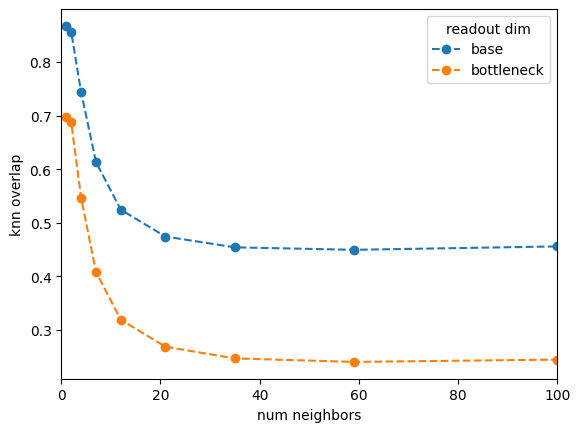

In [76]:
labels = ['base', 'bottleneck']
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, label=label, ls='--', marker='o')

plt.legend(title='readout dim')
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_bottleneck.png')
plt.show()